<a href="https://colab.research.google.com/github/gamzedrn/Softito-Egitim-Calismalari/blob/main/ai_assistant_usage_student_life_eda_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kütüphanelerin yüklenmesi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version:  {np.__version__}')
print(f'Seaborn version:{sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version:  2.0.2
Seaborn version:0.13.2


## Veri Yükle

In [ ]:
df = pd.read_csv('ai_assistant_usage_student_life.csv')

print('\nAI Asistan Kullanımı - Öğrenci Verisi')
print('=' * 50)
print(f'Boyut      : {df.shape[0]} satır, {df.shape[1]} sütun')
print(f'Bellek     : {df.memory_usage(deep=True).sum() / 1024:.2f} KB')
print('=' * 50)


AI Asistan Kullanımı - Öğrenci Verisi
Boyut      : 10000 satır, 11 sütun
Bellek     : 3837.24 KB


In [ ]:
print('\nİlk 5 Satır:')
df.head()



İlk 5 Satır:


,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.00
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.00
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.30
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.50
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.90


In [ ]:
print('\nson beş satır:')
df.tail()


son beş satır:


,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
9995,SESSION09996,Undergraduate,Psychology,2024-07-20,28.41,5,Studying,3,Assignment Completed,True,4.20
9996,SESSION09997,High School,Business,2024-11-11,13.98,6,Writing,5,Assignment Completed,True,5.00
9997,SESSION09998,Undergraduate,Biology,2024-09-11,10.78,2,Studying,3,Idea Drafted,True,3.50
9998,SESSION09999,Undergraduate,Business,2024-10-27,30.88,7,Writing,3,Assignment Completed,False,4.30
9999,SESSION10000,Undergraduate,Math,2025-04-16,10.85,3,Writing,4,Assignment Completed,True,4.90


In [ ]:
#rastgele beş satır
df.sample(5)

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
4642,SESSION04643,Graduate,Engineering,2024-08-08,38.66,13,Writing,4,Idea Drafted,True,2.80
3656,SESSION03657,Undergraduate,Biology,2024-08-19,7.96,2,Writing,5,Assignment Completed,True,4.10
7762,SESSION07763,Undergraduate,Psychology,2024-07-10,28.89,11,Writing,3,Assignment Completed,True,3.60
9509,SESSION09510,Undergraduate,Computer Science,2024-09-06,24.66,6,Writing,3,Assignment Completed,True,1.70
5965,SESSION05966,High School,Business,2024-12-30,38.21,10,Writing,3,Assignment Completed,True,3.70


## VERİ TİPLERİ VE TEMEL BİLGİLER

In [ ]:
print('\n--- Veri Tipleri ve Eksik Değer Özeti ---')
dtype_df = pd.DataFrame({
    'Sütun'       : df.columns,
    'Veri Tipi'   : df.dtypes.values,
    'Null Sayısı' : df.isnull().sum().values,
    'Null Oranı %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique'      : df.nunique().values
})
print(dtype_df.to_string(index=False))

df.info()

# Sayısal değişkenlerin temel istatistikleri
print('\n--- Sayısal Değişkenler ---')
display(df.describe().T)

# Kategorik değişkenlerin temel istatistikleri
print('\n--- Kategorik Değişkenler ---')
display(df.describe(include=['object', 'category']).T)


--- Veri Tipleri ve Eksik Değer Özeti ---
             Sütun Veri Tipi  Null Sayısı  Null Oranı %  Unique
         SessionID    object            0          0.00   10000
      StudentLevel    object            0          0.00       3
        Discipline    object            0          0.00       7
       SessionDate    object            0          0.00     366
  SessionLengthMin   float64            0          0.00    4078
      TotalPrompts     int64            0          0.00      37
          TaskType    object            0          0.00       6
AI_AssistanceLevel     int64            0          0.00       5
      FinalOutcome    object            0          0.00       4
         UsedAgain      bool            0          0.00       2
SatisfactionRating   float64            0          0.00      41
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              -------

,count,mean,std,min,25%,50%,75%,max
SessionLengthMin,10000.00,19.85,13.90,0.03,9.63,16.65,26.67,110.81
TotalPrompts,10000.00,5.61,4.65,1.00,2.00,4.00,8.00,39.00
AI_AssistanceLevel,10000.00,3.48,0.99,1.00,3.00,4.00,4.00,5.00
SatisfactionRating,10000.00,3.42,1.14,1.00,2.60,3.50,4.40,5.00



--- Kategorik Değişkenler ---


,count,unique,top,freq
SessionID,10000,10000,SESSION09984,1
StudentLevel,10000,3,Undergraduate,5978
Discipline,10000,7,Biology,1458
SessionDate,10000,366,2025-01-19,41
TaskType,10000,6,Writing,3101
FinalOutcome,10000,4,Assignment Completed,4768


## EKSİK VERİ ANALİZİ

In [ ]:
eksik       = df.isnull().sum()
eksik_oran  = (eksik / len(df) * 100).round(2)
eksik_df    = pd.concat([eksik, eksik_oran], axis=1)
eksik_df.columns = ['eksik_sayı', 'eksik_oran_%']
print('\n--- Eksik Veri Tablosu ---')
print(eksik_df.sort_values('eksik_oran_%', ascending=False))

# Eksik veri görselleştirmesi
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

if len(eksik_olan) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
              for x in (eksik_olan / len(df) * 100)]

    axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
    axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Eksik Değer Sayısı')
    for i, val in enumerate(eksik_olan.values):
        axes[0].text(val + 0.3, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

    sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[1])
    axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')

    plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Eksik veri bulunmuyor!')


--- Eksik Veri Tablosu ---
                    eksik_sayı  eksik_oran_%
SessionID                    0          0.00
StudentLevel                 0          0.00
Discipline                   0          0.00
SessionDate                  0          0.00
SessionLengthMin             0          0.00
TotalPrompts                 0          0.00
TaskType                     0          0.00
AI_AssistanceLevel           0          0.00
FinalOutcome                 0          0.00
UsedAgain                    0          0.00
SatisfactionRating           0          0.00
Eksik veri bulunmuyor!


EKSİK VERİ STRATEJİLERİ

In [ ]:
df_temiz = df.copy()

# Sayısal sütunlar → medyan ile doldur
sayisal_sutunlar    = df_temiz.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar  = df_temiz.select_dtypes(include=['object', 'category']).columns

for kolon in sayisal_sutunlar:
    if df_temiz[kolon].isnull().sum() > 0:
        medyan = df_temiz[kolon].median()
        df_temiz[kolon].fillna(medyan, inplace=True)
        print(f'{kolon} → medyan ({medyan:.2f}) ile dolduruldu')

# Kategorik sütunlar → mod ile doldur
for kolon in kategorik_sutunlar:
    if df_temiz[kolon].isnull().sum() > 0:
        mod = df_temiz[kolon].mode()[0]
        df_temiz[kolon].fillna(mod, inplace=True)
        print(f'{kolon} → mod ({mod}) ile dolduruldu')

print('\nTemizleme sonrası eksik değerler:')
print(df_temiz.isnull().sum())


Temizleme sonrası eksik değerler:
SessionID             0
StudentLevel          0
Discipline            0
SessionDate           0
SessionLengthMin      0
TotalPrompts          0
TaskType              0
AI_AssistanceLevel    0
FinalOutcome          0
UsedAgain             0
SatisfactionRating    0
dtype: int64


## TEK DEĞİŞKENLİ ANALİZ — SAYISAL DEĞİŞKENLER

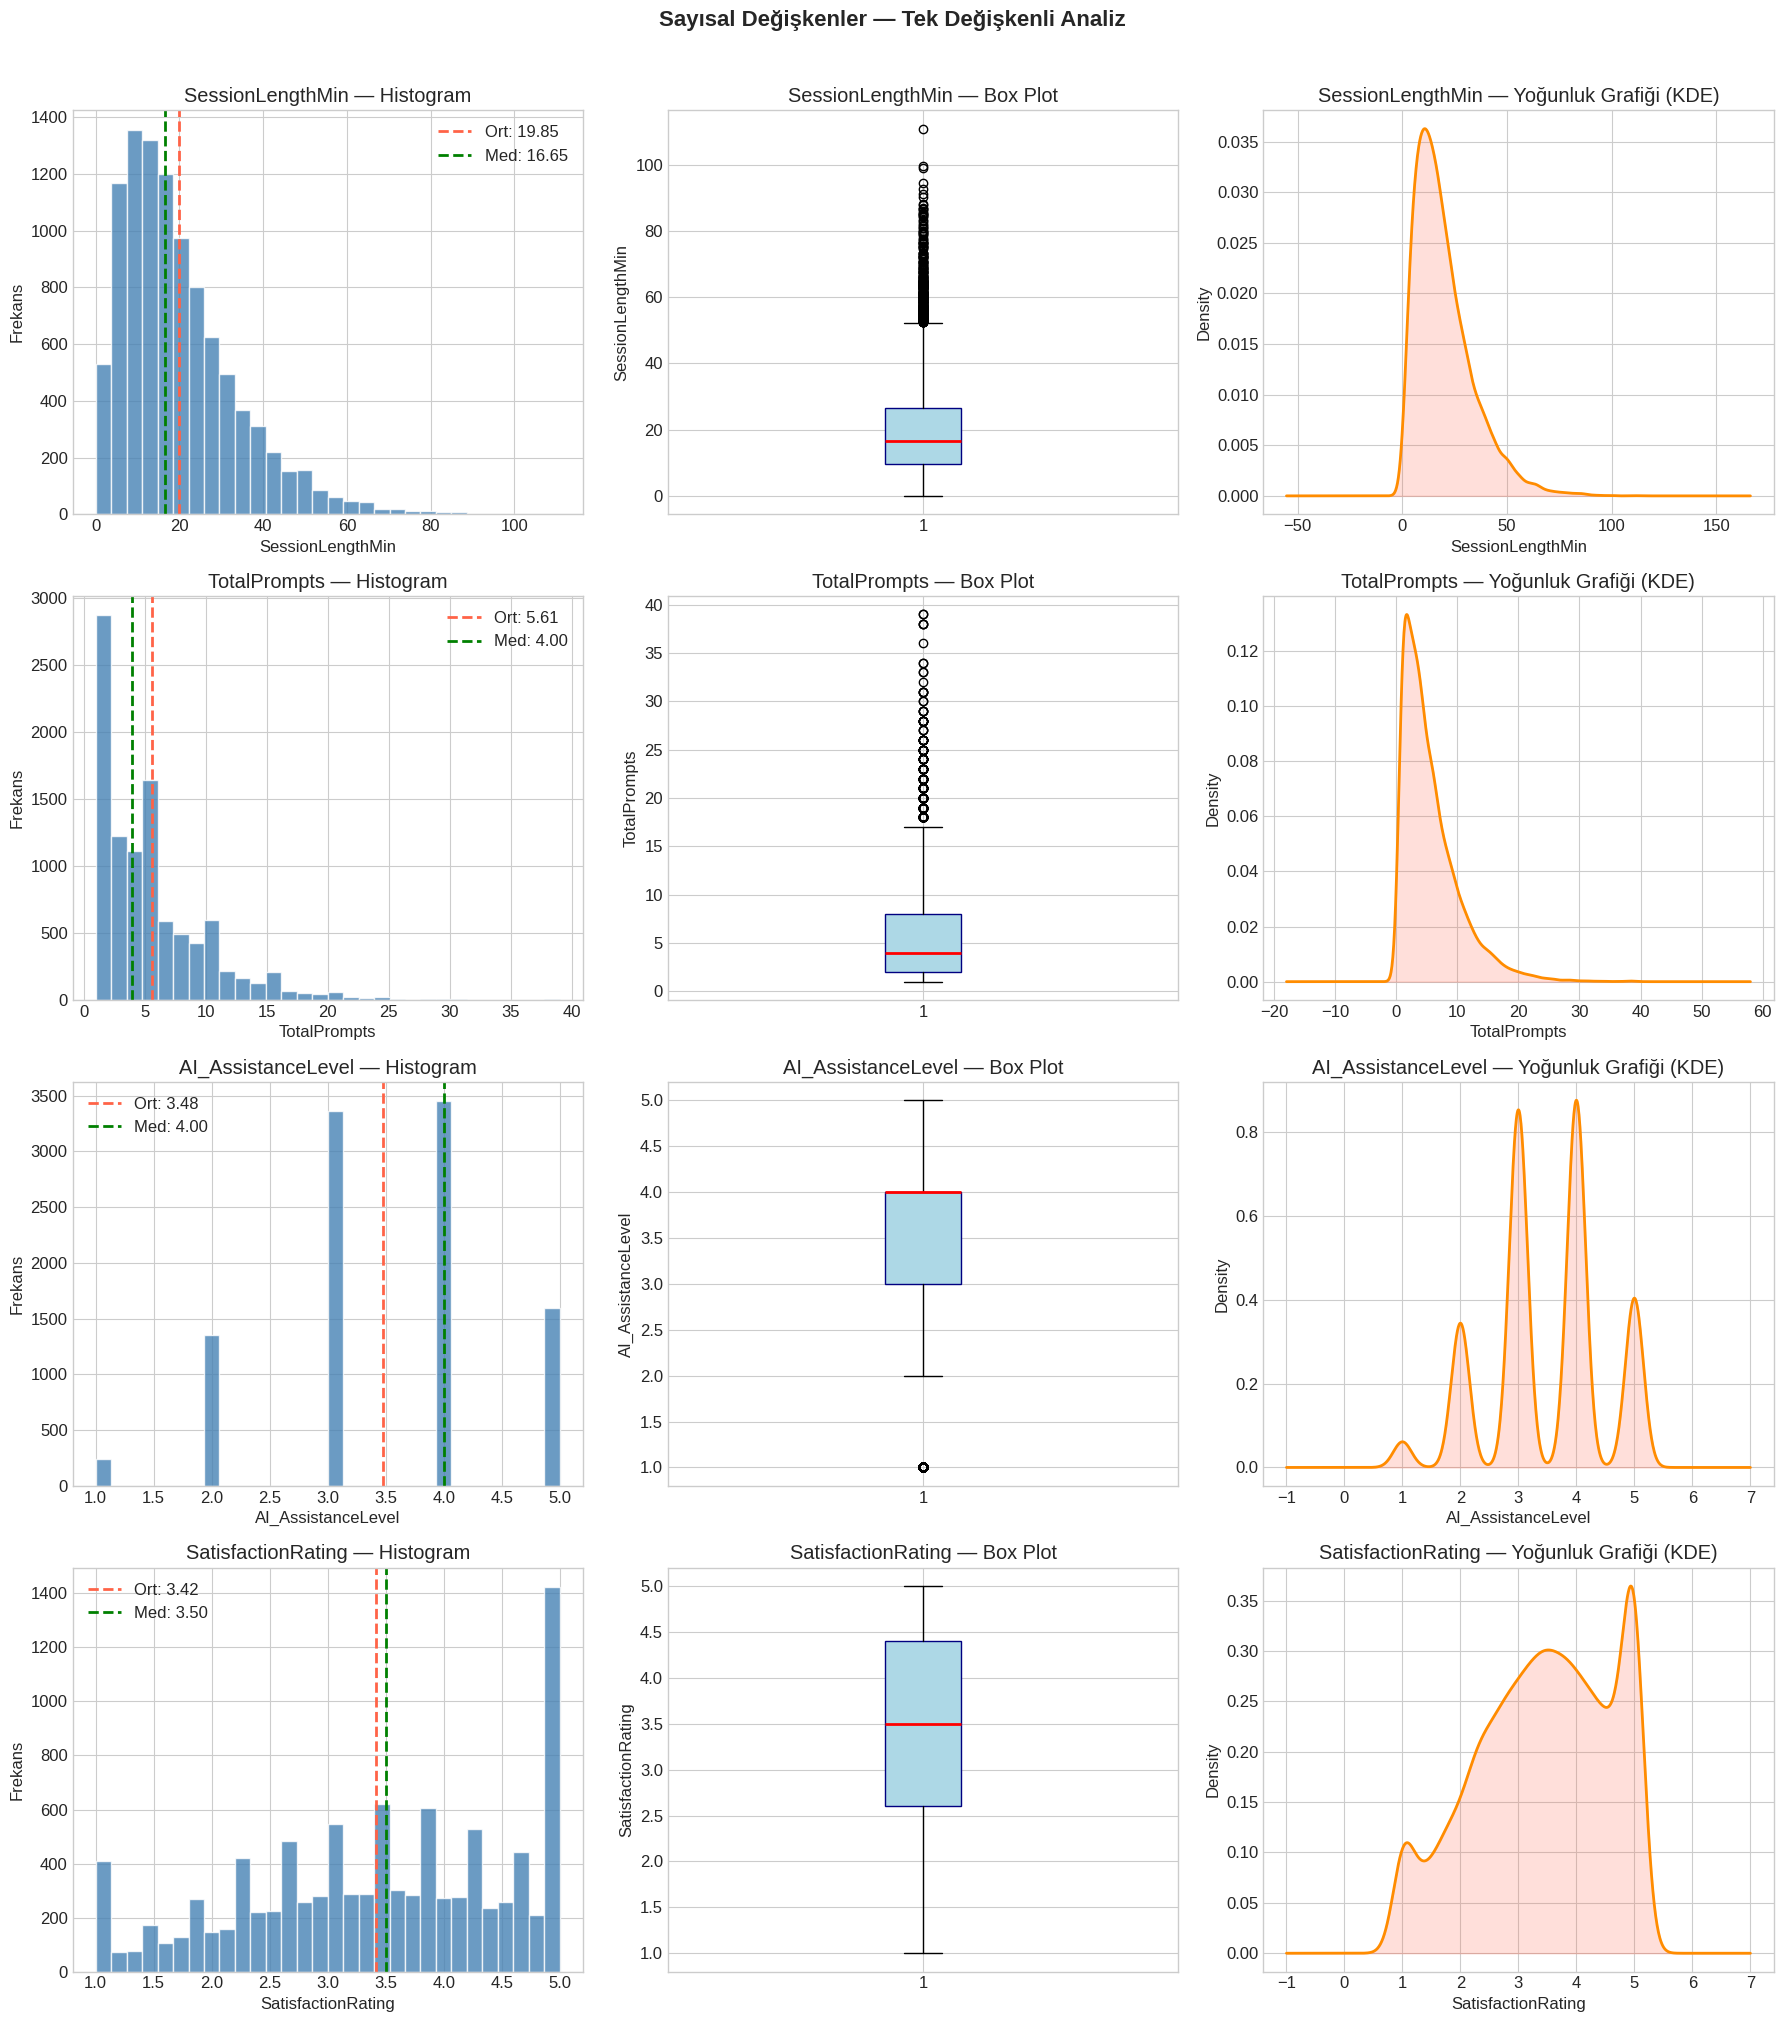


Sayısal Değişkenler — Detaylı İstatistikler

SESSIONLENGTHMIN
  Ortalama    : 19.85
  Medyan      : 16.65
  Std Sapma   : 13.90
  Min / Maks  : 0.03 / 110.81
  Çarpıklık   : 1.35
  Basıklık    : 2.45
  IQR         : 17.04

TOTALPROMPTS
  Ortalama    : 5.61
  Medyan      : 4.00
  Std Sapma   : 4.65
  Min / Maks  : 1.00 / 39.00
  Çarpıklık   : 1.77
  Basıklık    : 4.61
  IQR         : 6.00

AI_ASSISTANCELEVEL
  Ortalama    : 3.48
  Medyan      : 4.00
  Std Sapma   : 0.99
  Min / Maks  : 1.00 / 5.00
  Çarpıklık   : -0.24
  Basıklık    : -0.46
  IQR         : 1.00

SATISFACTIONRATING
  Ortalama    : 3.42
  Medyan      : 3.50
  Std Sapma   : 1.14
  Min / Maks  : 1.00 / 5.00
  Çarpıklık   : -0.34
  Basıklık    : -0.81
  IQR         : 1.80


In [ ]:

sayisal_kolonlar = ['SessionLengthMin', 'TotalPrompts', 'AI_AssistanceLevel', 'SatisfactionRating']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3, figsize=(18, 5 * len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
    veri = df_temiz[kolon].dropna()

    # Histogram
    axes[i, 0].hist(veri, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(veri.mean(),   color='tomato', linestyle='dashed', linewidth=2,
                       label=f'Ort: {veri.mean():.2f}')
    axes[i, 0].axvline(veri.median(), color='green',  linestyle='dashed', linewidth=2,
                       label=f'Med: {veri.median():.2f}')
    axes[i, 0].set_title(f'{kolon} — Histogram')
    axes[i, 0].legend()
    axes[i, 0].set_xlabel(kolon)
    axes[i, 0].set_ylabel('Frekans')

    # Box Plot
    axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{kolon} — Box Plot')
    axes[i, 1].set_ylabel(kolon)

    # KDE
    veri.plot.kde(ax=axes[i, 2], color='darkorange', linewidth=2)
    axes[i, 2].fill_between(axes[i, 2].lines[0].get_xdata(),
                            axes[i, 2].lines[0].get_ydata(),
                            color='tomato', alpha=0.2)
    axes[i, 2].set_title(f'{kolon} — Yoğunluk Grafiği (KDE)')
    axes[i, 2].set_xlabel(kolon)

plt.suptitle('Sayısal Değişkenler — Tek Değişkenli Analiz',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# İstatistiksel özet
print('\nSayısal Değişkenler — Detaylı İstatistikler')
print('=' * 70)
for kolon in sayisal_kolonlar:
    veri = df_temiz[kolon].dropna()
    print(f'\n{kolon.upper()}')
    print(f'  Ortalama    : {veri.mean():.2f}')
    print(f'  Medyan      : {veri.median():.2f}')
    print(f'  Std Sapma   : {veri.std():.2f}')
    print(f'  Min / Maks  : {veri.min():.2f} / {veri.max():.2f}')
    print(f'  Çarpıklık   : {veri.skew():.2f}')
    print(f'  Basıklık    : {veri.kurtosis():.2f}')
    print(f'  IQR         : {veri.quantile(0.75) - veri.quantile(0.25):.2f}')
    print('=' * 70)

## TEK DEĞİŞKENLİ ANALİZ — KATEGORİK DEĞİŞKENLER

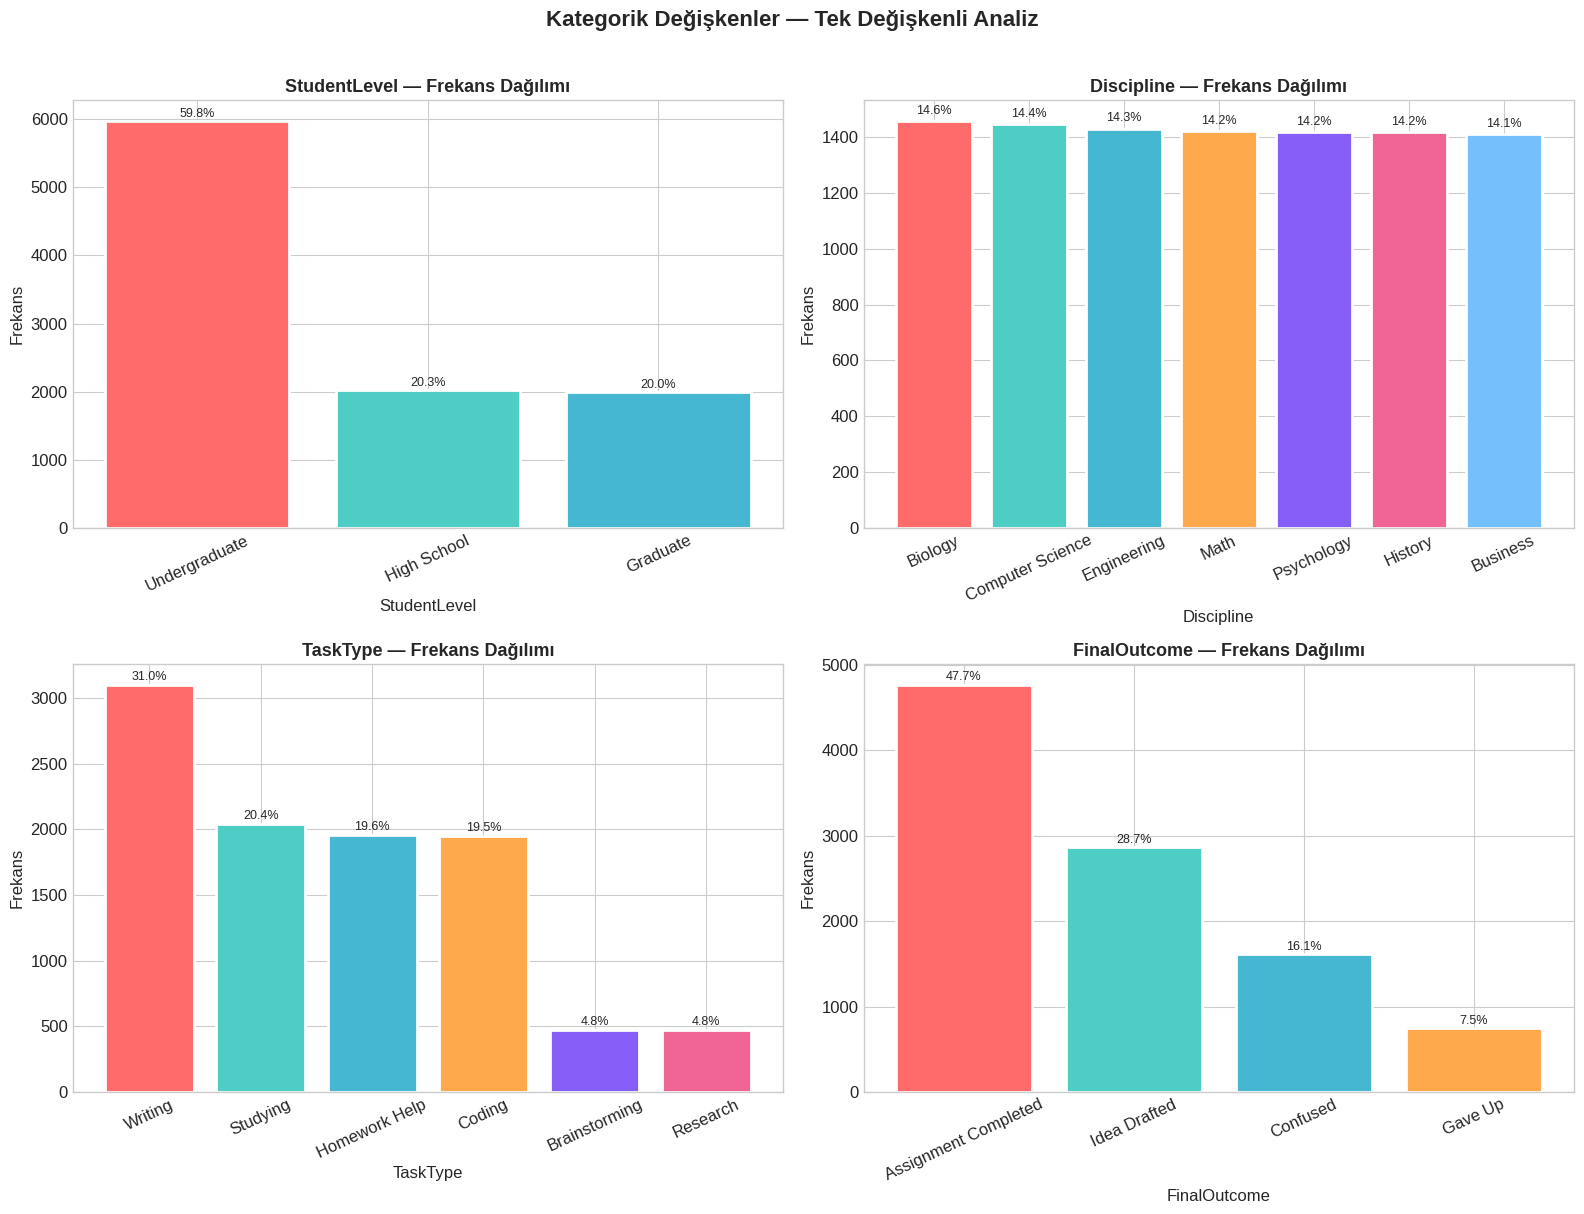

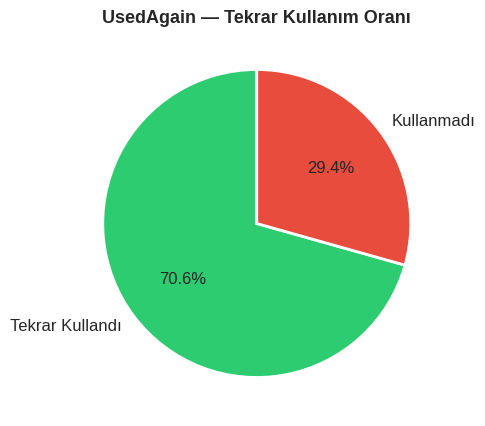

In [ ]:
kategorik_kolonlar = ['StudentLevel', 'Discipline', 'TaskType', 'FinalOutcome']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

renkler = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D',
           '#845EF7', '#F06595', '#74C0FC', '#63E6BE']

for i, kolon in enumerate(kategorik_kolonlar):
    degerler = df_temiz[kolon].value_counts()
    yuzde    = (degerler / len(df_temiz) * 100).round(1)

    bars = axes[i].bar(degerler.index.astype(str), degerler.values,
                       color=renkler[:len(degerler)], edgecolor='white', linewidth=2)
    axes[i].set_title(f'{kolon} — Frekans Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(kolon)
    axes[i].set_ylabel('Frekans')
    axes[i].tick_params(axis='x', rotation=25)

    for bar, pct in zip(bars, yuzde.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 15,
                     f'{pct}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Kategorik Değişkenler — Tek Değişkenli Analiz',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# UsedAgain (bool) ayrıca
fig, ax = plt.subplots(figsize=(6, 5))
used_counts = df_temiz['UsedAgain'].value_counts()
ax.pie(used_counts.values,
       labels=['Tekrar Kullandı', 'Kullanmadı'],
       autopct='%1.1f%%',
       colors=['#2ecc71', '#e74c3c'],
       startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('UsedAgain — Tekrar Kullanım Oranı', fontsize=13, fontweight='bold')
plt.show()

## ÇİFT DEĞİŞKENLİ ANALİZ

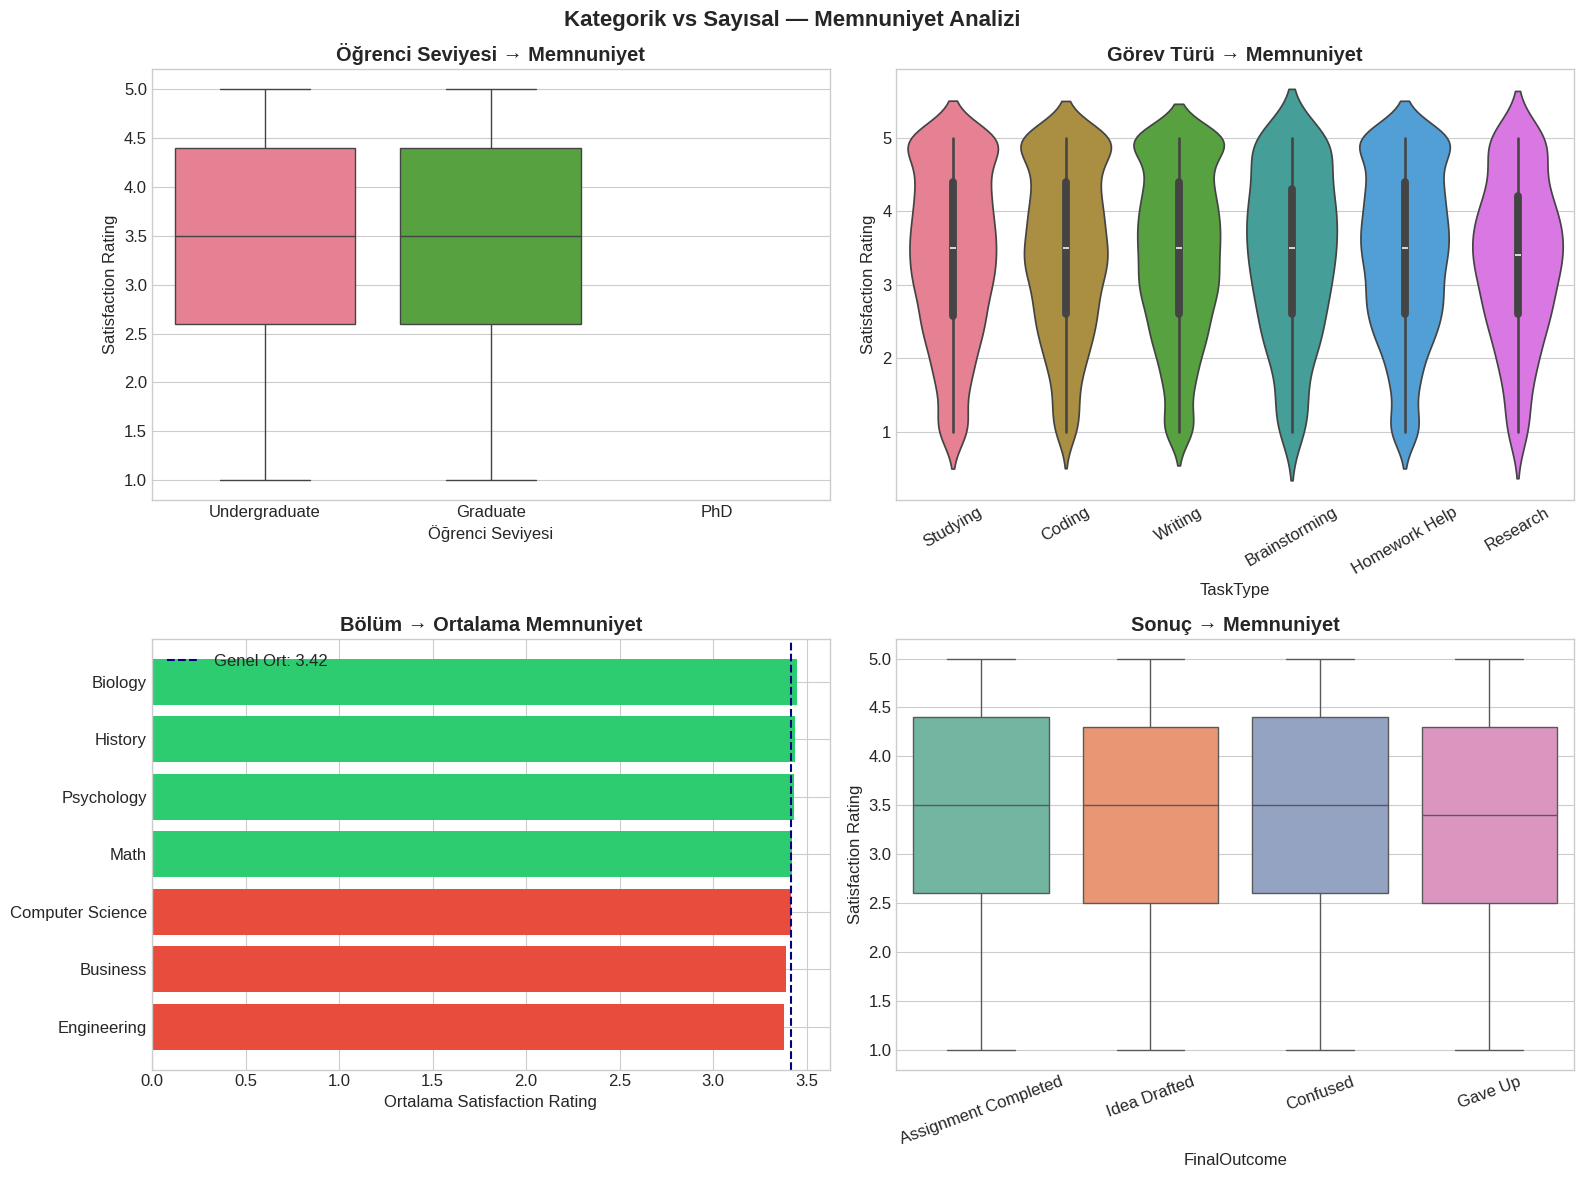

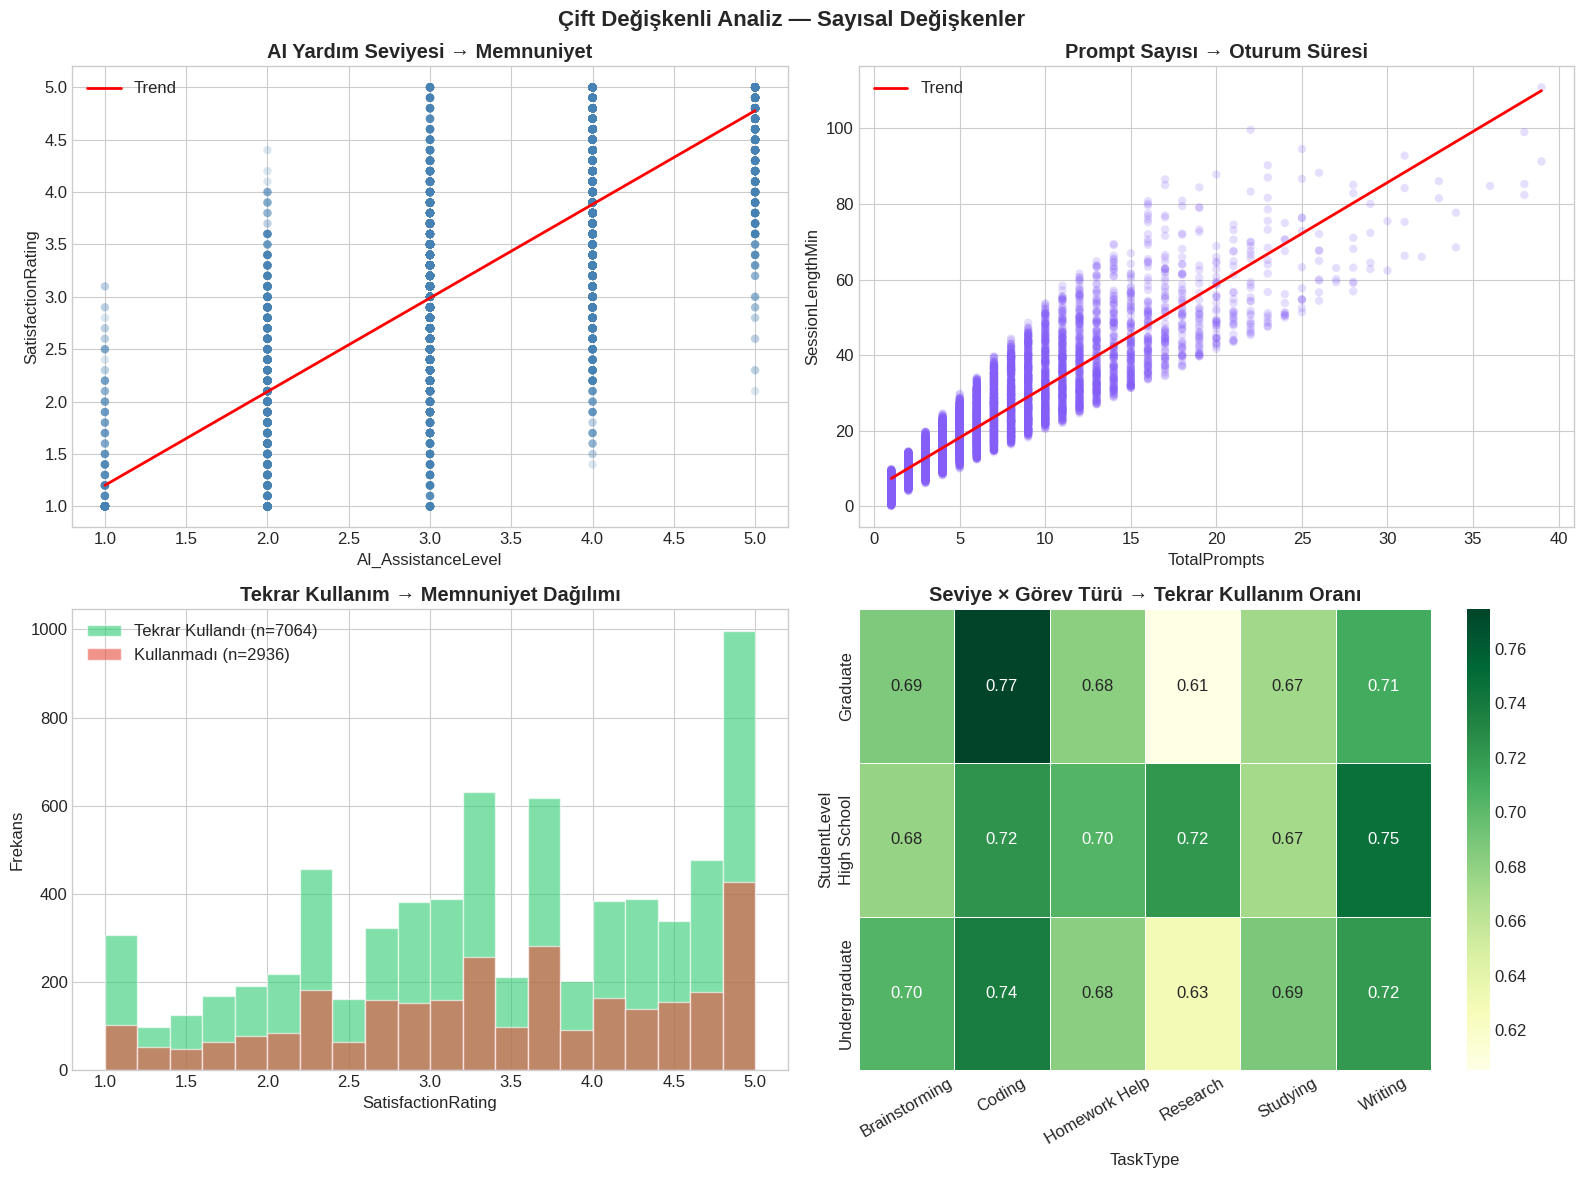

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) StudentLevel → SatisfactionRating
sns.boxplot(data=df_temiz, x='StudentLevel', y='SatisfactionRating',
            ax=axes[0, 0], palette='husl',
            order=['Undergraduate', 'Graduate', 'PhD'])
axes[0, 0].set_title('Öğrenci Seviyesi → Memnuniyet', fontweight='bold')
axes[0, 0].set_xlabel('Öğrenci Seviyesi')
axes[0, 0].set_ylabel('Satisfaction Rating')

# 2) TaskType → SatisfactionRating
sns.violinplot(data=df_temiz, x='TaskType', y='SatisfactionRating',
               ax=axes[0, 1], palette='husl')
axes[0, 1].set_title('Görev Türü → Memnuniyet', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].set_ylabel('Satisfaction Rating')

# 3) Discipline → SatisfactionRating
discipline_ort = df_temiz.groupby('Discipline')['SatisfactionRating'].mean().sort_values()
colors_disc = ['#e74c3c' if x < df_temiz['SatisfactionRating'].mean()
               else '#2ecc71' for x in discipline_ort.values]
axes[1, 0].barh(discipline_ort.index, discipline_ort.values, color=colors_disc)
axes[1, 0].axvline(df_temiz['SatisfactionRating'].mean(),
                   color='navy', linestyle='--', linewidth=1.5,
                   label=f'Genel Ort: {df_temiz["SatisfactionRating"].mean():.2f}')
axes[1, 0].set_title('Bölüm → Ortalama Memnuniyet', fontweight='bold')
axes[1, 0].set_xlabel('Ortalama Satisfaction Rating')
axes[1, 0].legend()

# 4) FinalOutcome → SatisfactionRating
sns.boxplot(data=df_temiz, x='FinalOutcome', y='SatisfactionRating',
            ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Sonuç → Memnuniyet', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].set_ylabel('Satisfaction Rating')

plt.suptitle('Kategorik vs Sayısal — Memnuniyet Analizi',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 5) AI_AssistanceLevel → SatisfactionRating (scatter + trend)
axes[0, 0].scatter(df_temiz['AI_AssistanceLevel'],
                   df_temiz['SatisfactionRating'],
                   alpha=0.2, color='steelblue', edgecolors='none')
# trend çizgisi
z = np.polyfit(df_temiz['AI_AssistanceLevel'], df_temiz['SatisfactionRating'], 1)
p = np.poly1d(z)
x_line = np.linspace(1, 5, 100)
axes[0, 0].plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
axes[0, 0].set_title('AI Yardım Seviyesi → Memnuniyet', fontweight='bold')
axes[0, 0].set_xlabel('AI_AssistanceLevel')
axes[0, 0].set_ylabel('SatisfactionRating')
axes[0, 0].legend()

# 6) TotalPrompts → SessionLengthMin
axes[0, 1].scatter(df_temiz['TotalPrompts'],
                   df_temiz['SessionLengthMin'],
                   alpha=0.2, color='#845EF7', edgecolors='none')
z2 = np.polyfit(df_temiz['TotalPrompts'], df_temiz['SessionLengthMin'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df_temiz['TotalPrompts'].min(), df_temiz['TotalPrompts'].max(), 100)
axes[0, 1].plot(x_line2, p2(x_line2), color='red', linewidth=2, label='Trend')
axes[0, 1].set_title('Prompt Sayısı → Oturum Süresi', fontweight='bold')
axes[0, 1].set_xlabel('TotalPrompts')
axes[0, 1].set_ylabel('SessionLengthMin')
axes[0, 1].legend()

# 7) UsedAgain → SatisfactionRating
used_labels = {True: 'Tekrar Kullandı', False: 'Kullanmadı'}
for val, renk in [(True, '#2ecc71'), (False, '#e74c3c')]:
    subset = df_temiz[df_temiz['UsedAgain'] == val]['SatisfactionRating']
    axes[1, 0].hist(subset, bins=20, alpha=0.6, color=renk,
                    label=f'{used_labels[val]} (n={len(subset)})', edgecolor='white')
axes[1, 0].set_title('Tekrar Kullanım → Memnuniyet Dağılımı', fontweight='bold')
axes[1, 0].set_xlabel('SatisfactionRating')
axes[1, 0].set_ylabel('Frekans')
axes[1, 0].legend()

# 8) StudentLevel & TaskType → UsedAgain oranı
pivot_used = df_temiz.groupby(['StudentLevel', 'TaskType'])['UsedAgain'].mean().unstack()
sns.heatmap(pivot_used, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Seviye × Görev Türü → Tekrar Kullanım Oranı', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('Çift Değişkenli Analiz — Sayısal Değişkenler',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## KATEGORİK vs KATEGORİK

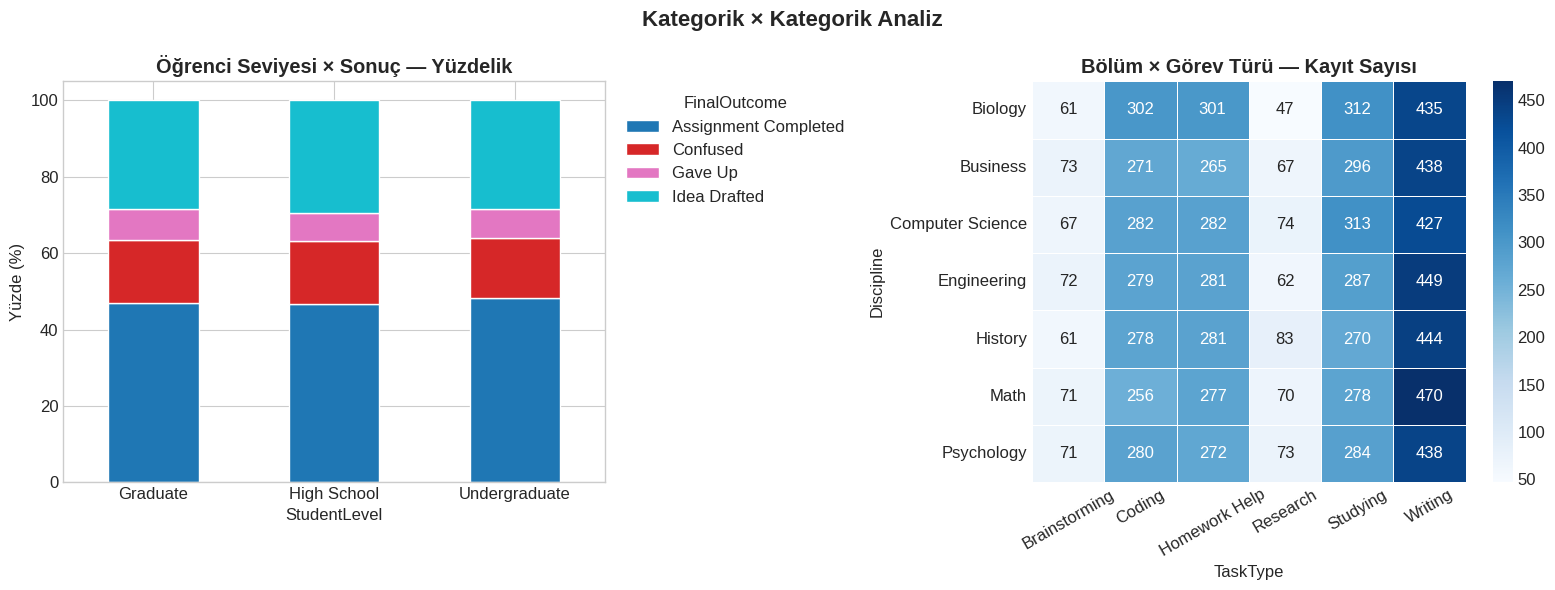

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# StudentLevel × FinalOutcome
ct_pct = pd.crosstab(df_temiz['StudentLevel'], df_temiz['FinalOutcome'],
                     normalize='index') * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[0],
            colormap='tab10', edgecolor='white')
axes[0].set_title('Öğrenci Seviyesi × Sonuç — Yüzdelik', fontweight='bold')
axes[0].set_xlabel('StudentLevel')
axes[0].set_ylabel('Yüzde (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='FinalOutcome', bbox_to_anchor=(1.01, 1), loc='upper left')

# Discipline × TaskType heatmap
ct2 = pd.crosstab(df_temiz['Discipline'], df_temiz['TaskType'])
sns.heatmap(ct2, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Bölüm × Görev Türü — Kayıt Sayısı', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Kategorik × Kategorik Analiz',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## KORELASYON MATRİSİ

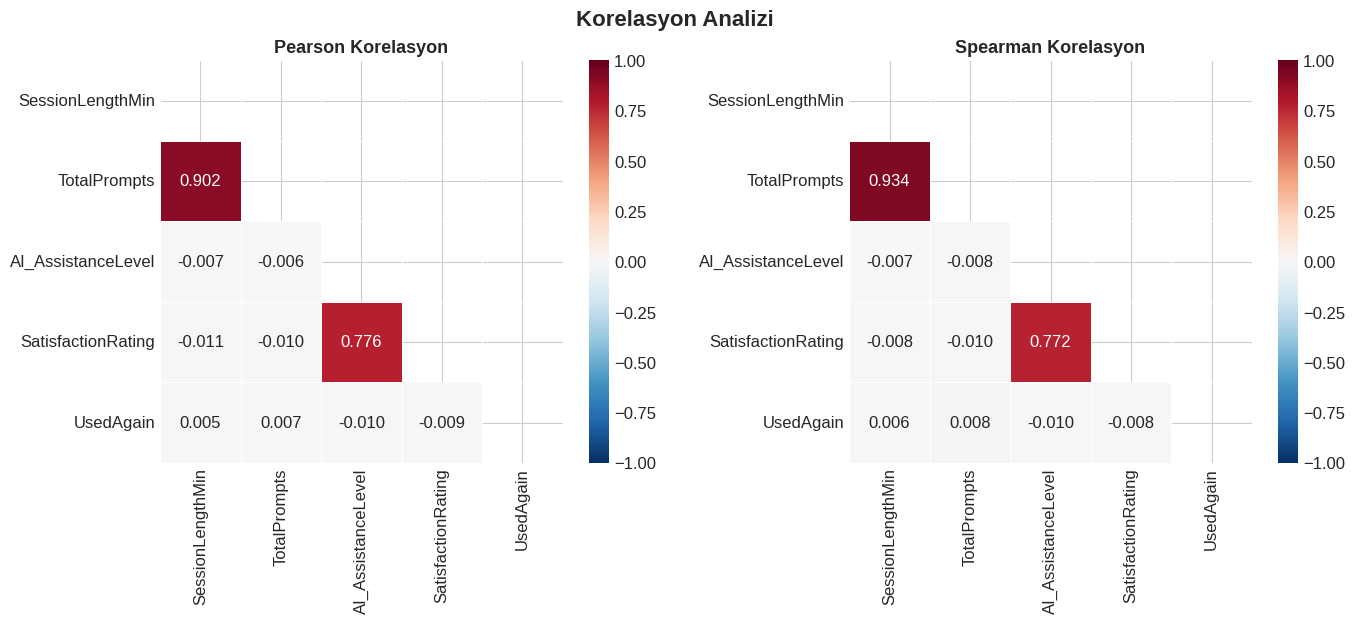


SatisfactionRating ile Korelasyon (Pearson):
AI_AssistanceLevel    0.78
UsedAgain            -0.01
TotalPrompts         -0.01
SessionLengthMin     -0.01
Name: SatisfactionRating, dtype: float64


In [ ]:
# UsedAgain bool → int'e çevir
df_corr = df_temiz[sayisal_kolonlar].copy()
df_corr['UsedAgain'] = df_temiz['UsedAgain'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))

# Pearson
pearson_corr = df_corr.corr(method='pearson')
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Korelasyon', fontsize=13, fontweight='bold')

# Spearman
spearman_corr = df_corr.corr(method='spearman')
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman Korelasyon', fontsize=13, fontweight='bold')

plt.suptitle('Korelasyon Analizi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# SatisfactionRating ile korelasyon sıralaması
print('\nSatisfactionRating ile Korelasyon (Pearson):')
print(pearson_corr['SatisfactionRating'].drop('SatisfactionRating').sort_values(ascending=False))

## ZAMANSERİSİ ANALİZİ

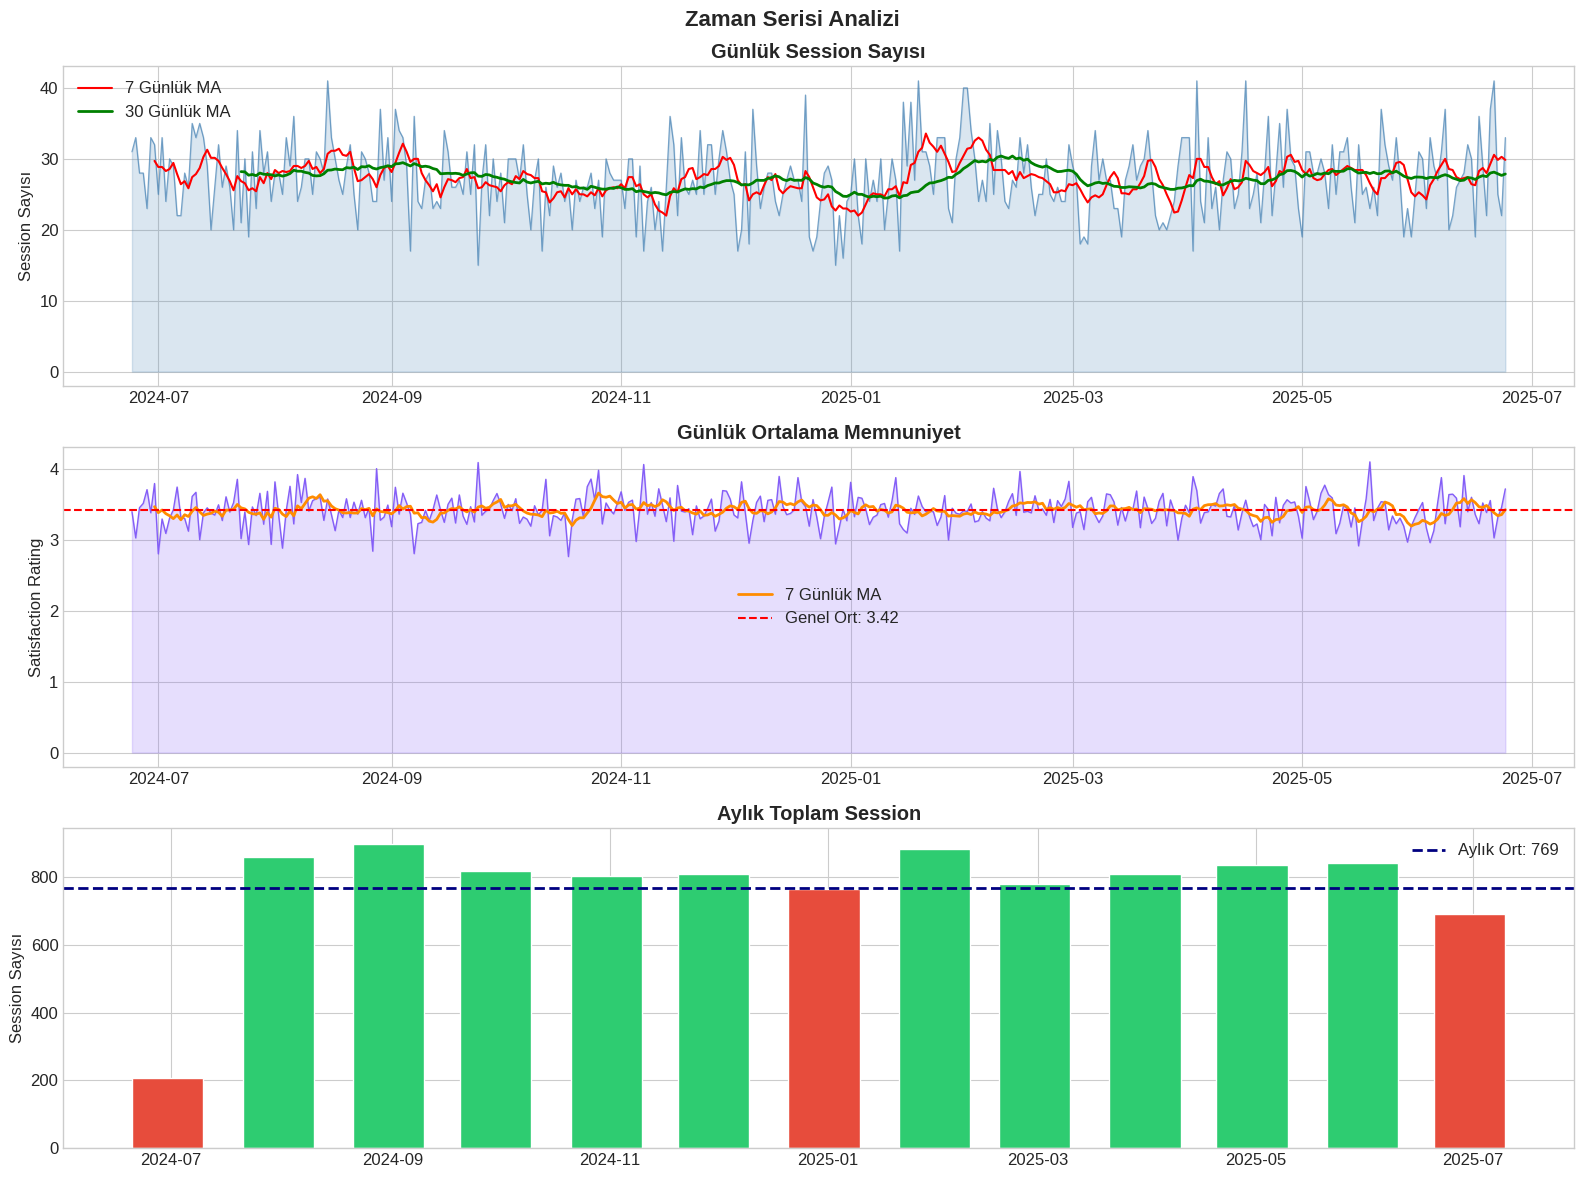

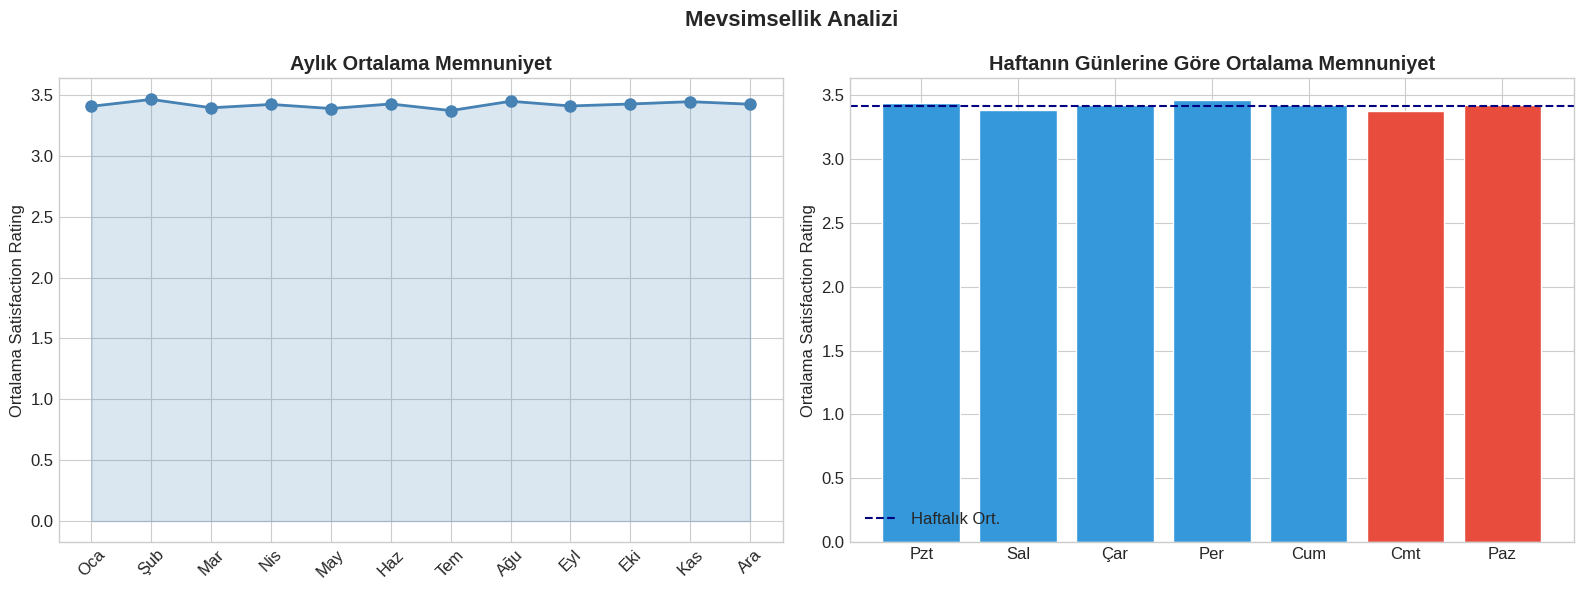

In [ ]:
# SessionDate → datetime
df_temiz['SessionDate'] = pd.to_datetime(df_temiz['SessionDate'])
df_temiz = df_temiz.sort_values('SessionDate')

# Günlük session sayısı
gunluk = df_temiz.resample('D', on='SessionDate').agg(
    session_sayisi=('SessionID', 'count'),
    ort_memnuniyet=('SatisfactionRating', 'mean'),
    ort_sure=('SessionLengthMin', 'mean')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Günlük kullanım
axes[0].plot(gunluk['SessionDate'], gunluk['session_sayisi'],
             color='steelblue', alpha=0.7, linewidth=0.9)
axes[0].fill_between(gunluk['SessionDate'], gunluk['session_sayisi'],
                     alpha=0.2, color='steelblue')

# 7 ve 30 günlük hareketli ortalama
gunluk['MA7']  = gunluk['session_sayisi'].rolling(7).mean()
gunluk['MA30'] = gunluk['session_sayisi'].rolling(30).mean()
axes[0].plot(gunluk['SessionDate'], gunluk['MA7'],  color='red',   linewidth=1.5, label='7 Günlük MA')
axes[0].plot(gunluk['SessionDate'], gunluk['MA30'], color='green', linewidth=2,   label='30 Günlük MA')
axes[0].set_title('Günlük Session Sayısı', fontweight='bold')
axes[0].set_ylabel('Session Sayısı')
axes[0].legend()

# Günlük ortalama memnuniyet
axes[1].plot(gunluk['SessionDate'], gunluk['ort_memnuniyet'],
             color='#845EF7', linewidth=1)
axes[1].fill_between(gunluk['SessionDate'], gunluk['ort_memnuniyet'],
                     alpha=0.2, color='#845EF7')
gunluk['MA7_sat'] = gunluk['ort_memnuniyet'].rolling(7).mean()
axes[1].plot(gunluk['SessionDate'], gunluk['MA7_sat'],
             color='darkorange', linewidth=2, label='7 Günlük MA')
axes[1].axhline(df_temiz['SatisfactionRating'].mean(),
                color='red', linestyle='--', linewidth=1.5,
                label=f'Genel Ort: {df_temiz["SatisfactionRating"].mean():.2f}')
axes[1].set_title('Günlük Ortalama Memnuniyet', fontweight='bold')
axes[1].set_ylabel('Satisfaction Rating')
axes[1].legend()

# Aylık toplam session — bar chart
aylik = df_temiz.resample('ME', on='SessionDate').size()
renkler_ay = ['#2ecc71' if x >= aylik.mean() else '#e74c3c' for x in aylik.values]
axes[2].bar(aylik.index, aylik.values, color=renkler_ay, width=20, edgecolor='white')
axes[2].axhline(aylik.mean(), color='navy', linestyle='--', linewidth=2,
                label=f'Aylık Ort: {aylik.mean():.0f}')
axes[2].set_title('Aylık Toplam Session', fontweight='bold')
axes[2].set_ylabel('Session Sayısı')
axes[2].legend()

plt.suptitle('Zaman Serisi Analizi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Aylık mevsimsellik — ay ve haftanın günü

df_temiz['ay']      = df_temiz['SessionDate'].dt.month
df_temiz['gun_adi'] = df_temiz['SessionDate'].dt.day_name()
df_temiz['yil']     = df_temiz['SessionDate'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ay_isimleri = ['Oca','Şub','Mar','Nis','May','Haz',
               'Tem','Ağu','Eyl','Eki','Kas','Ara']
aylik_ort = df_temiz.groupby('ay')['SatisfactionRating'].mean()
axes[0].plot(range(1, len(aylik_ort)+1), aylik_ort.values,
             'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].fill_between(range(1, len(aylik_ort)+1), aylik_ort.values,
                     alpha=0.2, color='steelblue')
axes[0].set_xticks(range(1, len(aylik_ort)+1))
axes[0].set_xticklabels(ay_isimleri[:len(aylik_ort)], rotation=45)
axes[0].set_title('Aylık Ortalama Memnuniyet', fontweight='bold')
axes[0].set_ylabel('Ortalama Satisfaction Rating')

gun_sirasi   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
gun_tr       = ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']
haftalik_ort = df_temiz.groupby('gun_adi')['SatisfactionRating'].mean().reindex(gun_sirasi)
renkler_gun  = ['#3498db'] * 5 + ['#e74c3c'] * 2
axes[1].bar(gun_tr, haftalik_ort.values, color=renkler_gun, edgecolor='white')
axes[1].set_title('Haftanın Günlerine Göre Ortalama Memnuniyet', fontweight='bold')
axes[1].set_ylabel('Ortalama Satisfaction Rating')
axes[1].axhline(haftalik_ort.mean(), color='navy', linestyle='--',
                linewidth=1.5, label='Haftalık Ort.')
axes[1].legend()

plt.suptitle('Mevsimsellik Analizi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


AYKIRLI DEĞER ANALİZİ (IQR)


Aykırı Değer Analizi (IQR Yöntemi)
SessionLengthMin       IQR=17.04  Alt=-15.93  Üst=52.23  Aykırı=302 (3.0%)
TotalPrompts           IQR=6.00  Alt=-7.00  Üst=17.00  Aykırı=265 (2.6%)
AI_AssistanceLevel     IQR=1.00  Alt=1.50  Üst=5.50  Aykırı=241 (2.4%)
SatisfactionRating     IQR=1.80  Alt=-0.10  Üst=7.10  Aykırı=0 (0.0%)


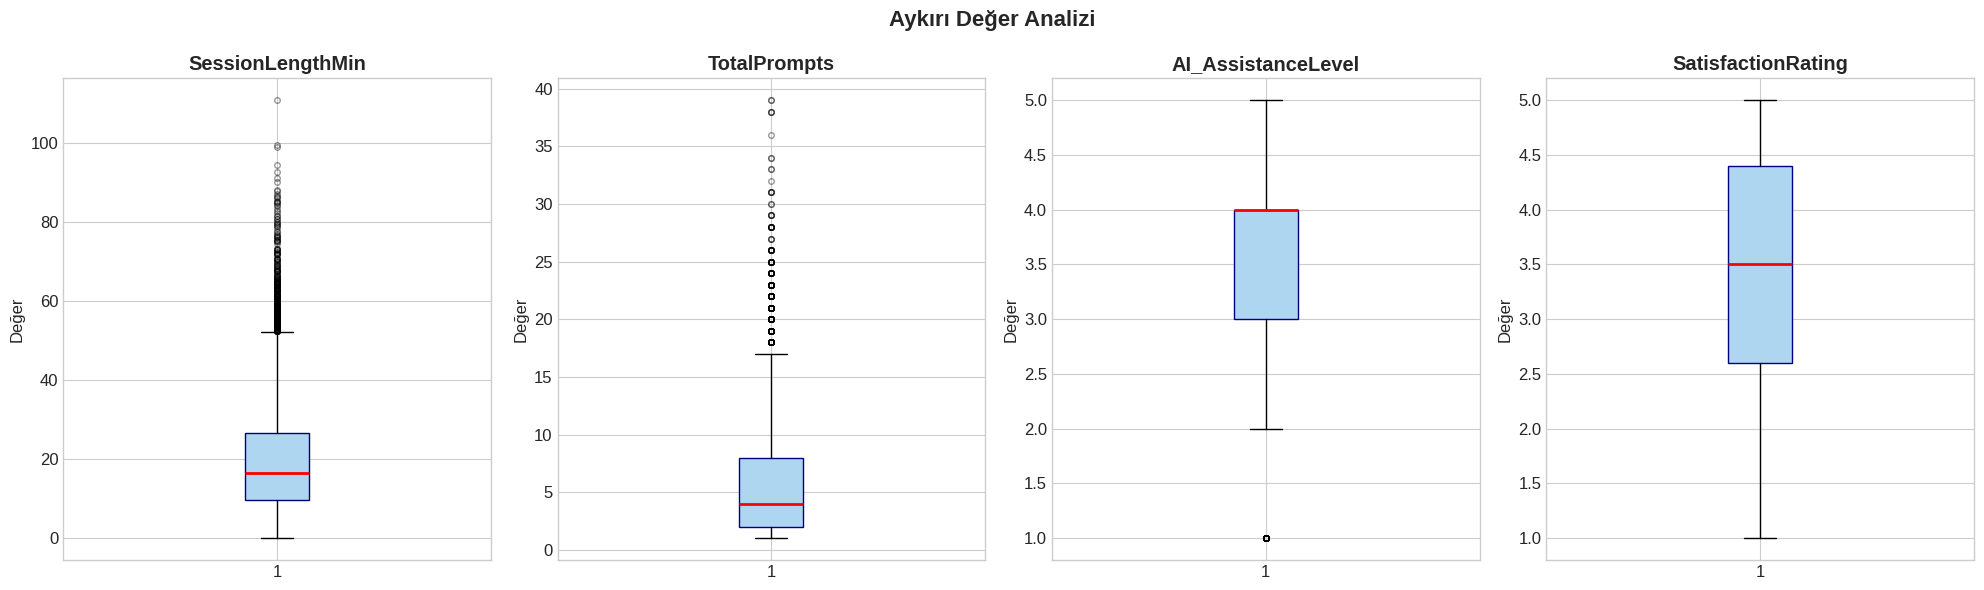

In [ ]:
print('\nAykırı Değer Analizi (IQR Yöntemi)')
print('=' * 65)

for kolon in sayisal_kolonlar:
    veri  = df_temiz[kolon]
    Q1    = veri.quantile(0.25)
    Q3    = veri.quantile(0.75)
    IQR   = Q3 - Q1
    alt   = Q1 - 1.5 * IQR
    ust   = Q3 + 1.5 * IQR
    n_ayk = ((veri < alt) | (veri > ust)).sum()
    print(f'{kolon:<22} IQR={IQR:.2f}  Alt={alt:.2f}  Üst={ust:.2f}  '
          f'Aykırı={n_ayk} ({n_ayk/len(veri)*100:.1f}%)')

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for i, kolon in enumerate(sayisal_kolonlar):
    axes[i].boxplot(df_temiz[kolon].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='red', alpha=0.4, markersize=4))
    axes[i].set_title(kolon, fontweight='bold')
    axes[i].set_ylabel('Değer')

plt.suptitle('Aykırı Değer Analizi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## EDA ÖZET RAPORU

In [ ]:
print('\n' + '=' * 60)
print('EDA ÖZET RAPORU — AI Student Usage')
print('=' * 60)
print(f'  Toplam kayıt          : {len(df_temiz):,}')
print(f'  Toplam sütun          : {df_temiz.shape[1]}')
print(f'  Eksik değer           : {df_temiz.isnull().sum().sum()}')
print(f'  Tarih aralığı         : {df_temiz["SessionDate"].min().date()} → {df_temiz["SessionDate"].max().date()}')
print(f'  En popüler görev türü : {df_temiz["TaskType"].mode()[0]}')
print(f'  En çok kullanılan bölüm: {df_temiz["Discipline"].mode()[0]}')
print(f'  Ort. oturum süresi    : {df_temiz["SessionLengthMin"].mean():.1f} dk')
print(f'  Ort. memnuniyet       : {df_temiz["SatisfactionRating"].mean():.2f} / 5')
print(f'  Tekrar kullanım oranı : %{df_temiz["UsedAgain"].mean()*100:.1f}')


EDA ÖZET RAPORU — AI Student Usage
  Toplam kayıt          : 10,000
  Toplam sütun          : 14
  Eksik değer           : 0
  Tarih aralığı         : 2024-06-24 → 2025-06-24
  En popüler görev türü : Writing
  En çok kullanılan bölüm: Biology
  Ort. oturum süresi    : 19.8 dk
  Ort. memnuniyet       : 3.42 / 5
  Tekrar kullanım oranı : %70.6
